## Day 1 - Calibrate Greeks

### Imports

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
from src.curves import Curve, par_swap_rate
from src.trades import load_trades, IRS, EuropeanSwaption
from src.pricers.irs import price_irs

TRADES_PATH = '../data/trades.parquet'
CURVES_PATH = '../data/market_data/curves_{}_D1.parquet'
CAPVOL_PATH = '../data/market_data/cap_vols_D1.parquet'
CS_PATH = '../data/market_data/credit_spreads_D1.parquet'
SWOPT_PATH = '../data/market_data/swaption_cube_D1.parquet'

### Load Trades

In [2]:
trades = load_trades(TRADES_PATH)

n_trades = len(trades)

print(10*'='+' TRADES '+10*'=', '\n')
print(f'Number of trades: {n_trades}')

========== TRADES ========== 

Number of trades: 202


### Load D1 Market Data

In [3]:
# Curves
eur_crv = pd.read_parquet(CURVES_PATH.format('EUR'))
usd_crv = pd.read_parquet(CURVES_PATH.format('USD'))

# CapVols
capvols = pd.read_parquet(CAPVOL_PATH)

# Credit Spreads
credit_spreads = pd.read_parquet(CS_PATH)

# Swaptions
swopts = pd.read_parquet(SWOPT_PATH)

### Load Curves
- Load trades.parquet + D1 market data. Skim dataclasses

In [4]:
# Load discount curve objects

curves = {
    'USD': Curve(usd_crv['tenor_y'].values, usd_crv['zero_rate'].values),
    'EUR': Curve(eur_crv['tenor_y'].values, eur_crv['zero_rate'].values)
}

curves

{'USD': Curve(tenors_y=array([ 0.083,  0.25 ,  0.5  ,  1.   ,  2.   ,  3.   ,  5.   ,  7.   ,
        10.   , 20.   , 30.   ]), zero_rates=array([0.0428, 0.042 , 0.041 , 0.0395, 0.038 , 0.037 , 0.0365, 0.037 ,
        0.038 , 0.039 , 0.04  ]), name='OIS'),
 'EUR': Curve(tenors_y=array([ 0.083,  0.25 ,  0.5  ,  1.   ,  2.   ,  3.   ,  5.   ,  7.   ,
        10.   , 20.   , 30.   ]), zero_rates=array([0.0335, 0.0325, 0.031 , 0.029 , 0.027 , 0.026 , 0.0255, 0.0265,
        0.0275, 0.0285, 0.0295]), name='OIS')}

### Model Validation Check
- Bootstrap OIS + projection curves (D1). Round-trip par swap rates from the curve — sanity check, not optional

In [5]:

tenors = [1.0, 5.0, 10.0]
rows = []

for tenor in tenors:
    for ccy in curves.keys():
        trade_id = f'{tenor}y swap'
        start = 0
        end = tenor
        pay_rec = 'payer'
        pay_freq = 1
        fix_dcc = 'act/360' if ccy == 'USD' else '30/360'
        flt_dcc = 'act/360'
        rate, _ = par_swap_rate(curves[ccy], curves[ccy], start, end)
        test_swap = IRS('test', 1, ccy, pay_rec, rate, start, end, pay_freq, fix_dcc, flt_dcc)
        npv = price_irs(test_swap, curves[ccy])
        rows.append([trade_id, ccy, rate, npv])

rate_chk = pd.DataFrame(rows, columns=['trade_id', 'ccy', 'par_swap_rate', 'npv'])

for ccy in list(rate_chk['ccy'].unique()):
    df = rate_chk[rate_chk['ccy'] == ccy].copy()
    
    print(10*'='+f' {ccy} IRS '+10*'=')
    print('\n')
    print(f'Validation table:\n\n{df.head().to_string()}\n')

    avg_zero = np.isclose(df['npv'], np.zeros_like(df['npv'])).mean()
    max_abs_npv = abs(df['npv'].max())

    print(f'Pct zero NPV: {avg_zero:.2%}')
    print(f'Max absolute NPV {max_abs_npv:.8f}\n')

========== USD IRS ==========


Validation table:

     trade_id  ccy  par_swap_rate  npv
0   1.0y swap  USD       0.040290  0.0
2   5.0y swap  USD       0.037240  0.0
4  10.0y swap  USD       0.038593  0.0

Pct zero NPV: 100.00%
Max absolute NPV 0.00000000

========== EUR IRS ==========


Validation table:

     trade_id  ccy  par_swap_rate  npv
1   1.0y swap  EUR       0.029425  0.0
3   5.0y swap  EUR       0.025876  0.0
5  10.0y swap  EUR       0.027757  0.0

Pct zero NPV: 100.00%
Max absolute NPV 0.00000000



### SABR calibration
- SABR per (expiry × tail) cell on D1 swaption cube. β = 0.5 fixed; α from the ATM cubic; (ρ, ν) least-squares to smile. Residuals heatmap

In [83]:
from src.vol.sabr import sabr_lognormal_vol, sabr_atm_alpha, sabr_calibrate_cell

# calibration
swopts_F = swopts.copy() 
swopts_F['forward'] = swopts.apply(
    lambda t: par_swap_rate(
        curves['USD'], curves['USD'], t['expiry_y'], t['expiry_y'] + t['tail_y'])[0], axis=1
)

results = []
residuals = {}

# iterate expiry x tenor group
for k, d in swopts_F.groupby(['expiry_y', 'tail_y']):
    forward = d['forward'].iloc[0]
    expiry = d['expiry_y'].iloc[0]
    tenor = d['tail_y'].iloc[0]
    # calibration
    res = sabr_calibrate_cell(d['strike'].values, d['vol'].values, forward, expiry)
    # store results
    results.append([expiry, tenor, res['alpha'], res['beta'], res['rho'], res['nu'], res['sse']])

    # store residuals
    residuals[f'{int(expiry)}yx{int(tenor)}y'] = res['residuals'] * 10_000
    
calib_results = pd.DataFrame(results, columns=['expiry', 'tenor', 'alpha', 'beta', 'rho', 'nu', 'sse'])

print(f'Calibration results:\n\n{calib_results.to_string()}\n')

Calibration results:

   expiry  tenor     alpha  beta       rho        nu       sse
0     1.0    5.0  0.059764   0.5  0.453061  0.364484  0.000032
1     1.0   10.0  0.062794   0.5  0.990000  0.161619  0.000003
2     1.0   20.0  0.058247   0.5  0.469450  0.321041  0.000028
3     2.0    5.0  0.057209   0.5  0.990000  0.154469  0.000024
4     2.0   10.0  0.058534   0.5  0.990000  0.141394  0.000006
5     2.0   20.0  0.055786   0.5  0.990000  0.147787  0.000004
6     5.0    5.0  0.057647   0.5  0.750504  0.214042  0.000005
7     5.0   10.0  0.057999   0.5  0.632324  0.234022  0.000001
8     5.0   20.0  0.055784   0.5  0.990000  0.150615  0.000048



#### Residuals Heatmap

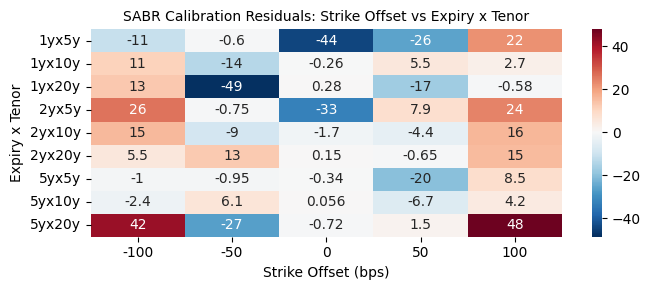


All SABR fit residuals under 50bp vol threshold


In [132]:
# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals data
strike_offsets = sorted(swopts['strike_offset_bp'].unique())
heatmap = pd.DataFrame(residuals, index=strike_offsets).T.round(4)

# Heatmap
plt.figure(figsize=(7, 3))
sns.heatmap(heatmap, cmap='RdBu_r', annot=True, center=0)
plt.title('SABR Calibration Residuals: Strike Offset vs Expiry x Tenor', fontsize=10)
plt.xlabel('Strike Offset (bps)')
plt.ylabel('Expiry x Tenor')
plt.tight_layout()
plt.show()

# Diagnosis
max_abs_residual = heatmap.abs().max().max()
vol_thresh_bps = 50
if max_abs_residual > vol_thresh_bps:
    print('\nOne or more points have a residual above the 50bp vol threshold.\n')
    for k, v in heatmap.stack().items():
        if abs(v) > vol_thresh_bps:
            print(f'[{k[0]}; strike_offset={k[1]}] residual is {v}; fail at {vol_thresh_bps}bp threshold')
else:
    print(f'\nAll SABR fit residuals under {vol_thresh_bps}bp vol threshold')

### LMM CapVol Bootstrap
- LMM caplet-vol bootstrap from cap strip. Forward-by-forward cumulative-variance root-find

In [161]:
swopts_F.iloc[25:30]

,expiry_y,tail_y,strike_offset_bp,strike,vol,forward
25,2.0,20.0,-100,0.030,0.281502,0.03974
26,2.0,20.0,-50,0.035,0.281121,0.03974
27,2.0,20.0,0,0.040,0.282683,0.03974
28,2.0,20.0,50,0.045,0.283028,0.03974
29,2.0,20.0,100,0.050,0.281677,0.03974


In [162]:
df1 = curves['USD'].DF(2)
df2 = curves['USD'].DF(22)

ann = sum([curves['USD'].DF(i) for i in range(3, 23)])
(df1 - df2) / ann

np.float64(0.039739880838743316)